<a href="https://colab.research.google.com/github/Dhruvansh-Shah/MY1stRepo/blob/main/sentiment_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas nltk requests

In [ ]:
import pandas as pd
import nltk
import requests

print("All libraries imported successfully")

All libraries imported successfully


In [ ]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [ ]:
import requests
import pandas as pd

API_KEY = "4249469b1be949ecb428901791364cfe"

url = "https://newsapi.org/v2/everything"

params = {
    "q": "Infosys",
    "language": "en",
    "pageSize": 100,
    "sortBy": "publishedAt",
    "apiKey": API_KEY
}

response = requests.get(url, params=params)
data = response.json()

articles = data["articles"]

rows = []
for article in articles:
    rows.append({
        "date": article["publishedAt"][:10],
        "headline": article["title"]
    })

df_news = pd.DataFrame(rows)

print("Number of articles fetched:", len(df_news))
df_news.head()

Number of articles fetched: 100


,date,headline
0,2026-01-20,"Rs 8,600 crore selloff! Infosys most sold stoc..."
1,2026-01-20,Republic Day to lift ecommerce sales; Shadowfa...
2,2026-01-20,"After Q3 beats, is Indian IT turning the corner?"
3,2026-01-20,Nifty Equal Weight Index returns a lot more th...
4,2026-01-20,ReNew lines up $500-million dollar bond issue


In [ ]:
from nltk.tokenize import word_tokenize

# Take the first headline as a sample
sample_headline = df_news.loc[0, "headline"]

print("Sample headline:")
print(sample_headline)

tokens = word_tokenize(sample_headline.lower())

print("\nTokens:")
print(tokens)

Sample headline:
Rs 8,600 crore selloff! Infosys most sold stock by mutual funds in December. Time for a U-turn?

Tokens:
['rs', '8,600', 'crore', 'selloff', '!', 'infosys', 'most', 'sold', 'stock', 'by', 'mutual', 'funds', 'in', 'december', '.', 'time', 'for', 'a', 'u-turn', '?']


In [ ]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
from nltk.corpus import stopwords
import string

# Download stopwords (safe to run)
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

clean_tokens = [
    word for word in tokens
    if word.isalpha() and word not in stop_words
]

print("Clean tokens:")
print(clean_tokens)

Clean tokens:
['rs', 'crore', 'selloff', 'infosys', 'sold', 'stock', 'mutual', 'funds', 'december', 'time']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
# Simple finance-oriented sentiment lexicon
positive_words = {
    "profit", "profits", "growth", "gain", "gains", "strong",
    "positive", "up", "increase", "rises", "bullish", "optimistic"
}

negative_words = {
    "loss", "losses", "selloff", "fall", "falls", "down",
    "decline", "negative", "risk", "uncertainty", "bearish"
}

sentiment_score = 0

for word in clean_tokens:
    if word in positive_words:
        sentiment_score += 1
    elif word in negative_words:
        sentiment_score -= 1

print("Sentiment score for this headline:", sentiment_score)

Sentiment score for this headline: -1


In [ ]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def compute_sentiment(headline):
    tokens = word_tokenize(headline.lower())
    clean_tokens = [
        w for w in tokens
        if w.isalpha() and w not in stop_words
    ]

    score = 0
    for w in clean_tokens:
        if w in positive_words:
            score += 1
        elif w in negative_words:
            score -= 1
    return score

# Apply sentiment to all headlines
df_news["sentiment"] = df_news["headline"].apply(compute_sentiment)

# Aggregate per day
daily_sentiment = (
    df_news
    .groupby("date")["sentiment"]
    .sum()
    .reset_index()
)

daily_sentiment

,date,sentiment
0,2026-01-16,9
1,2026-01-17,-2
2,2026-01-18,4
3,2026-01-19,5
4,2026-01-20,0


In [ ]:
# Save daily sentiment to CSV
daily_sentiment.to_csv("daily_sentiment.csv", index=False)

print("daily_sentiment.csv saved")

daily_sentiment.csv saved


In [ ]:
from google.colab import files
files.download("daily_sentiment.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install yfinance

In [ ]:
import yfinance as yf
import pandas as pd

# Infosys ticker on NSE
ticker = "INFY.NS"

# Download last 1 year of daily data
price_data = yf.download(
    ticker,
    period="1y",
    interval="1d"
)

# Reset index to get date as column
price_data = price_data.reset_index()

# Keep only date and close price
prices = price_data[["Date", "Close"]]
prices.columns = ["date", "close"]

prices.head()

/tmp/ipython-input-1167339135.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  price_data = yf.download(
[*********************100%***********************]  1 of 1 completed


,date,close
0,2025-01-21,1748.941162
1,2025-01-22,1803.088745
2,2025-01-23,1811.829956
3,2025-01-24,1821.542603
4,2025-01-27,1769.628906


In [ ]:
import numpy as np

# Sort by date (safety)
prices = prices.sort_values("date")

# Compute daily log returns
prices["return"] = np.log(prices["close"] / prices["close"].shift(1))

# Drop the first NaN row
returns = prices[["date", "return"]].dropna()

returns.head()

,date,return
1,2025-01-22,0.030491
2,2025-01-23,0.004836
3,2025-01-24,0.005346
4,2025-01-27,-0.028914
5,2025-01-28,0.004245


In [ ]:
# Ensure date columns are the same type
daily_sentiment["date"] = pd.to_datetime(daily_sentiment["date"])
returns["date"] = pd.to_datetime(returns["date"])

# Merge on date
merged = pd.merge(daily_sentiment, returns, on="date", how="inner")

merged.head()

,date,sentiment,return
0,2026-01-16,9,0.054732
1,2026-01-19,5,-0.005102
2,2026-01-20,0,-0.013353


In [ ]:
# Test lead–lag correlations
max_lag = 5  # test up to 5 trading days
results = []

for lag in range(1, max_lag + 1):
    merged[f"sentiment_lag_{lag}"] = merged["sentiment"].shift(lag)
    corr = merged[f"sentiment_lag_{lag}"].corr(merged["return"])

    results.append({
        "lag_days": lag,
        "correlation": corr
    })

lead_lag_results = pd.DataFrame(results)
lead_lag_results

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


,lag_days,correlation
0,1,1.0
1,2,NaN
2,3,NaN
3,4,NaN
4,5,NaN


In [ ]:
merged.describe()
print("Rows in merged:", len(merged))
print("Unique sentiment values:", merged["sentiment"].unique())

Rows in merged: 3
Unique sentiment values: [9 5 0]


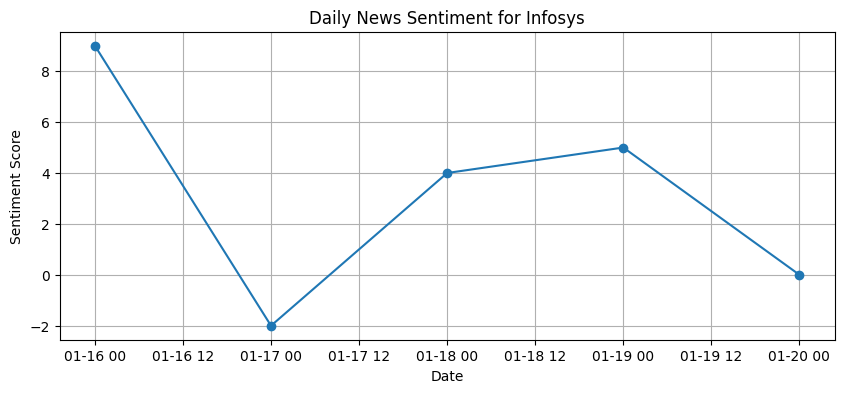

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(daily_sentiment["date"], daily_sentiment["sentiment"], marker="o")
plt.title("Daily News Sentiment for Infosys")
plt.xlabel("Date")
plt.ylabel("Sentiment Score")
plt.grid(True)
plt.show()

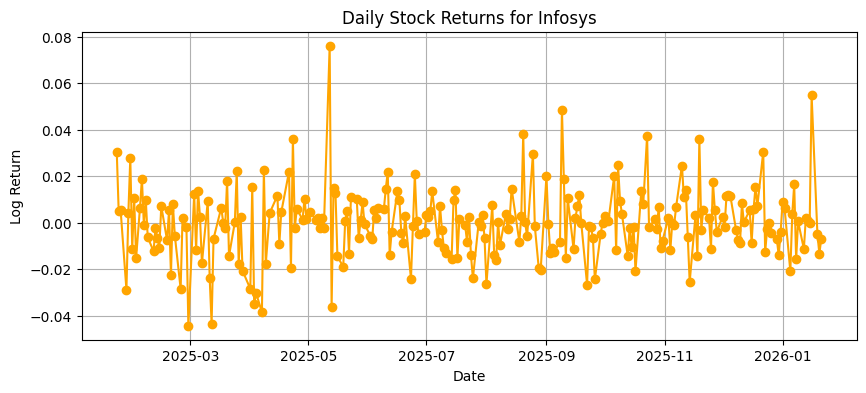

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(returns["date"], returns["return"], marker="o", color="orange")
plt.title("Daily Stock Returns for Infosys")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid(True)
plt.show()

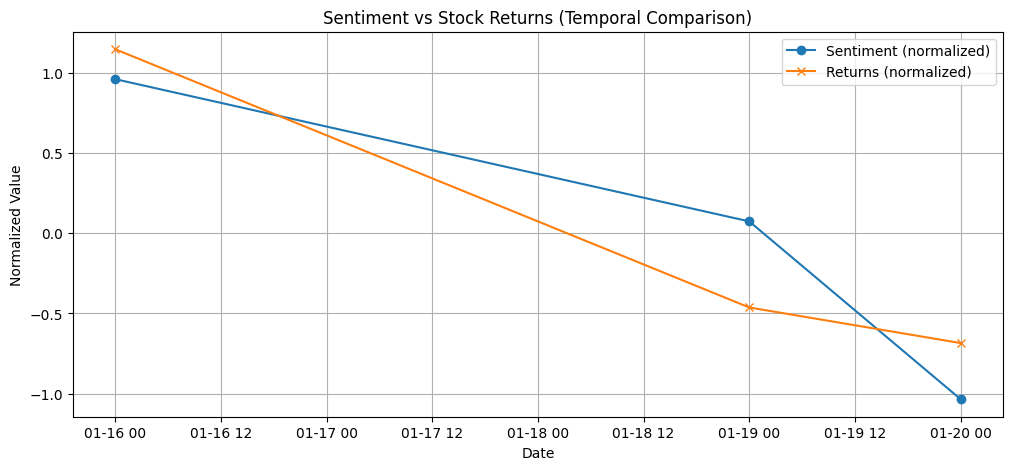

In [ ]:
# Normalize for visual comparison (important)
merged_plot = merged.copy()

merged_plot["sentiment_norm"] = (
    merged_plot["sentiment"] - merged_plot["sentiment"].mean()
) / merged_plot["sentiment"].std()

merged_plot["return_norm"] = (
    merged_plot["return"] - merged_plot["return"].mean()
) / merged_plot["return"].std()

plt.figure(figsize=(12, 5))

plt.plot(
    merged_plot["date"],
    merged_plot["sentiment_norm"],
    label="Sentiment (normalized)",
    marker="o"
)

plt.plot(
    merged_plot["date"],
    merged_plot["return_norm"],
    label="Returns (normalized)",
    marker="x"
)

plt.title("Sentiment vs Stock Returns (Temporal Comparison)")
plt.xlabel("Date")
plt.ylabel("Normalized Value")
plt.legend()
plt.grid(True)
plt.show()